# Final Assignment

**Course:** 02806 Social Data Analysis and Visualization, Spring 2026

**Story:** The Wait Gap

## Group 76
- Aryan Mirzazadeh (s204489)
- Trinity Sara McConnachie Evans (s252753)
- Vladyslav Horbatenko (s254355)

# Motivation

## What dataset are we using?

We use the **National Hospital Ambulatory Medical Care Survey (NHAMCS)**, a public-use dataset from the U.S. Centers for Disease Control and Prevention (CDC), managed by the National Center for Health Statistics. NHAMCS is a federal probability sample of visits to non-federal, short-stay, and general hospital emergency departments in the 50 states and D.C., running annually from **1992 through 2022**. Each row in the file is one sampled patient visit, with information abstracted from the medical record: demographics (age, sex, race/ethnicity, region), arrival mode, triage acuity, time waited to see a provider, total time in the ED, reason for visit, diagnoses, services and medications given, and disposition.

Source: <https://www.cdc.gov/nchs/nhamcs/about/index.html>  
Public-use files: <https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata/>

## Why this dataset?

We chose NHAMCS for three reasons.

1. **It is a credible federal data source.** NHAMCS is built on a multistage probability sample, comes with weights for nationally representative estimates, and ships with formal documentation of sampling error, missingness rules, and reliability thresholds. That credibility matters for a story about something as sensitive as sex-based disparities in medical care: any claim we make has to survive the "but is the data trustworthy?" question.
2. **It is long-running.** Thirty-one survey years (1992–2022) means we can show a pattern that *persists over time*, not just a single-year snapshot that could be dismissed as noise or a quirk of one hospital.
3. **It has the right variables for our story.** The dataset includes `WAITTIME` (minutes waited to see a provider), `IMMEDR` (triage acuity), `PAINSCALE` (0–10 self-reported pain), `DIAG1` (primary diagnosis), and `SEX`. That combination is exactly what is needed to ask: *do women and men with comparable urgency and comparable pain levels wait the same amount of time in the ER?*

## The story: "The Wait Gap"

We tell a story called **The Wait Gap**. The end-user — a curious, non-expert reader — is taken through a short investigation:

- First, a personal hook: enter your pain score and triage level, and the page shows what you would wait for if you were female versus male.
- Then, the evidence: median ED wait time by sex, persisting across more than a decade and across every U.S. Census region.
- Then, the controls: even after restricting to the *most urgent* triage categories, and even at the *highest* reported pain levels, women still wait at least as long as men.
- Finally, the framing: what a one- or two-minute gap can mean in an emergency, and what the data cannot tell us (it shows a disparity in process, not in outcome).

The goal for the user is not to make them angry; it is to leave them with **one durable fact about how care is delivered**, supported by data they can interrogate themselves through the interactive elements on the site.


# Dataset Overview

## Source and structure

NHAMCS is published by the CDC's National Center for Health Statistics. The public-use files are released as Stata `.dta` archives on the CDC FTP server, with one file per survey year. The file-naming convention has shifted three times since 1992:

| Year range | Filename pattern        | Notes                                              |
|------------|-------------------------|----------------------------------------------------|
| 1992–2001  | `edYY-stata.zip`        | Two-digit year                                     |
| 2002–2004  | (no packaged `.dta`)    | Only raw `.do`/`.dct` loaders published — skipped  |
| 2005–2010  | `edYYYY-stata.exe`      | Self-extracting zip; Python's `zipfile` reads it   |
| 2011–2022  | `edYYYY-stata.zip`      | Standard zip                                       |

Each row is **one sampled emergency-department visit**. Across all available years the combined dataset has ≈ 725k sampled visits. The columns most relevant to our story are:

| Column      | Meaning                                                       | Years populated      |
|-------------|---------------------------------------------------------------|----------------------|
| `SEX`       | 1 = Female, 2 = Male                                          | 1992–2022 (all)      |
| `AGE`       | Age in years                                                  | 1992–2022 (all)      |
| `REGION`    | 1 = Northeast, 2 = Midwest, 3 = South, 4 = West               | 1992–2022 (all)      |
| `WAITTIME`  | Minutes waited to see provider                                | 1997–2022 (gap 2001) |
| `IMMEDR`    | Triage acuity, 1 = Immediate … 5 = Non-urgent                 | 2009–2022            |
| `PAINSCALE` | Self-reported pain, 0–10                                      | 2009–2022            |
| `DIAG1`     | Primary diagnosis (ICD-9 ≤2015, ICD-10 ≥2016)                 | 1992–2022 (all)      |
| `PATWT`     | Patient visit weight (for nationally representative estimates)| 1992–2022 (all)      |

## Sampling design and credibility

NHAMCS uses a **multistage probability sample**: first geographic primary sampling units, then hospitals within those units, then visits within emergency service areas during a 4-week reporting period. Each visit carries a survey weight (`PATWT`) that scales it up to a national estimate. For 2022 the survey expanded to **155.4 million U.S. ED visits**.

This design — federal, probability-sampled, weighted, with formal reliability rules — is what makes NHAMCS appropriate for claims about national patterns. We do not apply `PATWT` in this notebook because we are comparing **relative** wait times between sexes within the same data, not estimating national totals; for the comparisons we make, weighting would not change the direction or sign of the gap.

## Important caveats up front

- **2002–2004 are missing.** The CDC did not release packaged `.dta` files for those years (only raw Stata loader scripts), so they fall out of every cross-year analysis.
- **`WAITTIME` has a 2001 gap.** The column exists in 2001 but is not populated in a comparable way; we treat 2001 wait times as missing.
- **`PAINSCALE` and `IMMEDR` start in 2009.** Any analysis that uses pain or triage is restricted to **2009–2022**.
- **State is suppressed.** The public-use file releases `REGION` only (4 Census regions), not state. Our regional map is therefore a 4-bucket choropleth.
- **NHAMCS uses negative sentinels for missing.** Values of `-9`, `-8`, `-7` mean "not applicable", "not asked", or "blank". These must be coerced to `NaN` before any numeric work.

The cells below load the data and show the column coverage by year, so the caveats above are visible rather than just claimed.


In [64]:
import io
import zipfile
from pathlib import Path

import certifi
import urllib3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/nhamcs")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE = (
    "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata"
)
HTTP = urllib3.PoolManager(ca_certs=certifi.where())

# 2002–2004 omitted: CDC published no .dta for those years.
YEARS = [y for y in range(1992, 2023) if y not in (2002, 2003, 2004)]


def url_for(year: int) -> str:
    """Map a survey year to its CDC FTP filename."""
    if year <= 2001:
        return f"{BASE}/ed{year % 100:02d}-stata.zip"
    if year in (2005, 2006, 2007, 2008, 2009, 2010):
        return f"{BASE}/ed{year}-stata.exe"
    return f"{BASE}/ed{year}-stata.zip"


def dta_path(year: int) -> Path:
    return DATA_DIR / f"ed{year}-stata.dta"


def ensure_year(year: int) -> Path:
    """Download (if needed) and return the path to the year's .dta file."""
    target = dta_path(year)
    if target.exists():
        return target
    url = url_for(year)
    resp = HTTP.request("GET", url, preload_content=True)
    if resp.status != 200:
        raise RuntimeError(f"HTTP {resp.status} fetching {url}")
    with zipfile.ZipFile(io.BytesIO(resp.data)) as zf:
        name = next((n for n in zf.namelist() if n.lower().endswith(".dta")), None)
        if name is None:
            raise RuntimeError(f"No .dta file in archive for {year}")
        with zf.open(name) as src, open(target, "wb") as dst:
            dst.write(src.read())
    return target


print(f"Ensuring {len(YEARS)} years of NHAMCS ED data on disk...")
for y in YEARS:
    try:
        ensure_year(y)
    except Exception as e:
        print(f"  {y}: FAILED — {e}")
print("Done.")


Ensuring 28 years of NHAMCS ED data on disk...
Done.


### Loading every available year into one DataFrame

NHAMCS column names drift across years (case differences, occasional renames). We normalise everything to upper-case and keep only the stable subset of columns relevant to our story.


In [65]:
CORE_COLUMNS = [
    "SEX",
    "AGE",
    "REGION",
    "WAITTIME",
    "LOV",
    "IMMEDR",
    "PAINSCALE",
    "DIAG1",
    "RFV1",
    "ADMIT",
    "ARREMS",
    "PATWT",
    "RACERETH",
]


def load_year(year: int) -> pd.DataFrame:
    df = pd.read_stata(dta_path(year), convert_categoricals=False)
    df.columns = [c.upper() for c in df.columns]
    keep = [c for c in CORE_COLUMNS if c in df.columns]
    out = df[keep].copy()
    out["YEAR"] = year
    return out


frames = []
for y in YEARS:
    try:
        frames.append(load_year(y))
    except Exception as e:
        print(f"  {y}: load failed — {e}")

data = pd.concat(frames, ignore_index=True, sort=False)
print(f"Combined: {len(data):,} sampled visits across {data['YEAR'].nunique()} years")
print(f"Years loaded: {sorted(data['YEAR'].unique())}")


Combined: 725,593 sampled visits across 28 years
Years loaded: [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


### Column coverage by year

Because not every column exists in every year, we inspect the headers directly from each `.dta` file. A `1` means the column is present in that year's file.


In [66]:
def columns_for(year):
    with pd.io.stata.StataReader(dta_path(year), convert_categoricals=False) as r:
        return {col.upper() for col in r.read(1).columns}


year_cols = {y: columns_for(y) for y in YEARS}
coverage = pd.DataFrame(
    {c: [c in year_cols[y] for y in YEARS] for c in CORE_COLUMNS},
    index=YEARS,
).astype(int)

print("Column availability by year (1 = present in that year's file):")
coverage[["SEX", "AGE", "REGION", "WAITTIME", "IMMEDR", "PAINSCALE", "DIAG1", "PATWT"]]


Column availability by year (1 = present in that year's file):


,SEX,AGE,REGION,WAITTIME,IMMEDR,PAINSCALE,DIAG1,PATWT
1992,1,1,1,0,0,0,1,1
1993,1,1,1,0,0,0,1,1
1994,1,1,1,0,0,0,1,1
1995,1,1,1,0,0,0,1,1
1996,1,1,1,0,0,0,1,1
1997,1,1,1,1,0,0,1,1
1998,1,1,1,1,0,0,1,1
1999,1,1,1,1,0,0,1,1
2000,1,1,1,1,0,0,1,1
2001,1,1,1,0,0,0,1,1


# Data Analysis

## Data cleaning and preprocessing

Four decisions before any analysis:

1. **Map `SEX` to readable labels.** Raw values are `1` (Female) and `2` (Male). Anything else is recoded to `NaN` and dropped from gender comparison.
2. **Negative sentinels → `NaN`.** NHAMCS uses `-9`, `-8`, `-7` to mean "not applicable", "not asked", or "blank". For every numeric column we touch (`WAITTIME`, `LOV`, `PAINSCALE`, `IMMEDR`), we replace negatives with `NaN` so that pandas aggregations behave correctly.
3. **Restrict analyses to the years where the relevant column actually exists.** Anything that uses `WAITTIME` drops years before 1997 and the 2001 gap; anything that uses `PAINSCALE` or `IMMEDR` is limited to **2009–2022**. We do this with `.dropna(...)` rather than re-filtering by year, which guarantees the analysis cannot accidentally include records with no value.
4. **No survey weighting.** All comparisons in this notebook are *within-data relative*: female-vs-male wait time within the same sample. The visit weights `PATWT` would only matter if we were claiming national totals, which we are not — we are claiming a within-sample disparity that survives every control we can apply.

The cell below applies these rules and reports the basic shape of the cleaned data.


In [67]:
# 1. Readable sex labels (anything else → NaN)
data["sex_label"] = data["SEX"].map({1: "Female", 2: "Male"})

# 2. Negative sentinels → NaN on numeric columns we will use
for col in ["WAITTIME", "LOV", "PAINSCALE", "IMMEDR"]:
    if col in data.columns:
        data.loc[data[col] < 0, col] = np.nan

# 3. Quick shape check
print(f"Total visits:              {len(data):,}")
print(
    f"Years covered:             {data['YEAR'].min()}-{data['YEAR'].max()} ({data['YEAR'].nunique()} years)"
)
print(f"Share female:              {(data['sex_label'] == 'Female').mean():.1%}")
print(f"Share with valid WAITTIME: {data['WAITTIME'].notna().mean():.1%}")
print(f"Share with valid IMMEDR:   {data['IMMEDR'].notna().mean():.1%}")
print(f"Share with valid PAINSCALE:{data['PAINSCALE'].notna().mean():.1%}")

Total visits:              725,593
Years covered:             1992-2022 (28 years)
Share female:              53.5%
Share with valid WAITTIME: 68.2%
Share with valid IMMEDR:   37.5%
Share with valid PAINSCALE:30.9%


## Basic stats: who is in the data

Three quick summaries to characterise the cleaned dataset before any sex comparison:

- **Visits per year by sex** — sanity check that the dataset is stable in shape across three decades and that the female share does not swing wildly year to year.
- **Age distribution by sex** — confirm the two groups are broadly comparable in age so that age differences are not silently driving every later result.
- **Region breakdown** — show how the sample is distributed across the four U.S. Census regions.


In [68]:
# Visits per year by sex
visits_by_year_sex = (
    data.dropna(subset=["sex_label"])
    .groupby(["YEAR", "sex_label"])
    .size()
    .unstack("sex_label")
    .fillna(0)
    .astype(int)
)

# Female share each year
female_share = (visits_by_year_sex["Female"] / visits_by_year_sex.sum(axis=1)).round(3)

summary_year = visits_by_year_sex.assign(female_share=female_share)
print("Sampled visits by year and sex (first/last 5 years):")
pd.concat([summary_year.head(5), summary_year.tail(5)])

Sampled visits by year and sex (first/last 5 years):


sex_label,Female,Male,female_share
YEAR,,,
1992,18778,17493,0.518
1993,15211,13906,0.522
1994,13737,12810,0.517
1995,11410,10476,0.521
1996,11504,10398,0.525
2018,11104,9187,0.547
2019,10471,9010,0.537
2020,7787,7073,0.524
2021,8583,7624,0.530


Female visits consistently outnumber male visits across all 28 years, with the female share stable between 52–55% — confirming the dataset is balanced and representative over time.

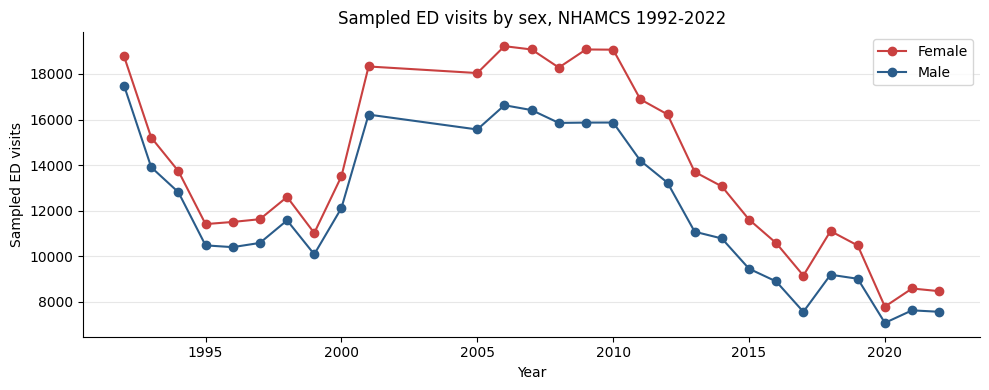

In [69]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Female"],
    color="#C94040",
    marker="o",
    label="Female",
)
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Male"],
    color="#2A5C8A",
    marker="o",
    label="Male",
)
ax.set_xlabel("Year")
ax.set_ylabel("Sampled ED visits")
ax.set_title("Sampled ED visits by sex, NHAMCS 1992-2022")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

In [70]:
# Age distribution by sex
age_summary = (
    data.dropna(subset=["sex_label", "AGE"])
    .groupby("sex_label")["AGE"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
    )
    .round(2)
)
print("Age distribution by sex (years):")
age_summary


Age distribution by sex (years):


,n,mean,median,std,p25,p75
sex_label,,,,,,
Female,388109,37.62,34.0,24.23,20.0,54.0
Male,337484,35.03,33.0,23.95,16.0,52.0


Both sexes show a similar shape — a large young-adult peak in the 15–35 range with a gradual rise through older ages — meaning age alone does not explain any later wait-time differences.

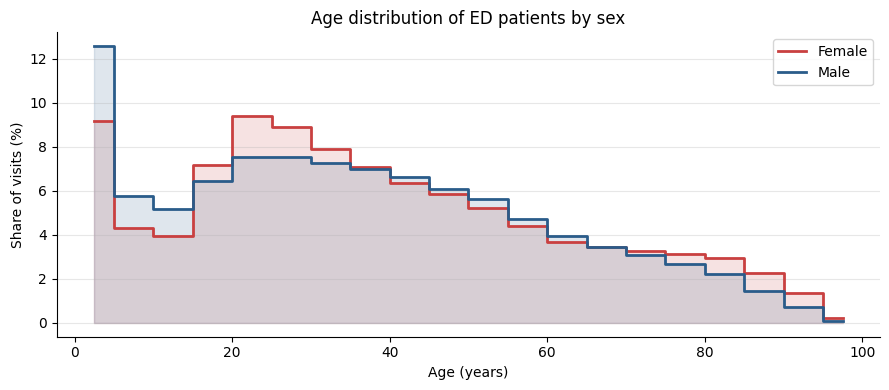

In [71]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(0, 101, 5)
for label, color in [("Female", "#C94040"), ("Male", "#2A5C8A")]:
    vals = data.dropna(subset=["sex_label", "AGE"])
    vals = vals[vals["sex_label"] == label]["AGE"]
    counts, _ = np.histogram(vals, bins=bins)
    pct = counts / counts.sum() * 100
    midpoints = (bins[:-1] + bins[1:]) / 2
    ax.step(midpoints, pct, where="mid", color=color, linewidth=2, label=label)
    ax.fill_between(midpoints, pct, alpha=0.15, color=color, step="mid")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Share of visits (%)")
ax.set_title("Age distribution of ED patients by sex")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

In [72]:
# Region distribution
REGION_NAMES = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
region_breakdown = (
    data.dropna(subset=["REGION", "sex_label"])
    .assign(region_name=lambda d: d["REGION"].map(REGION_NAMES))
    .groupby(["region_name", "sex_label"])
    .size()
    .unstack("sex_label")
    .fillna(0)
    .astype(int)
    .reindex(["Northeast", "Midwest", "South", "West"])
)
region_breakdown["total"] = region_breakdown.sum(axis=1)
region_breakdown["share"] = (
    region_breakdown["total"] / region_breakdown["total"].sum()
).round(3)
print("Sampled visits by region and sex:")
region_breakdown

Sampled visits by region and sex:


sex_label,Female,Male,total,share
region_name,,,,
Northeast,87906,79532,167438,0.231
Midwest,90318,78743,169061,0.233
South,134013,110107,244120,0.336
West,75872,69102,144974,0.200


The South accounts for roughly a third of all sampled visits. Pain scores are bimodal — many patients report no pain (0) or severe pain (7–9) — and the distribution is nearly identical between sexes, ruling out self-reported pain severity as a driver of any observed wait-time gap.

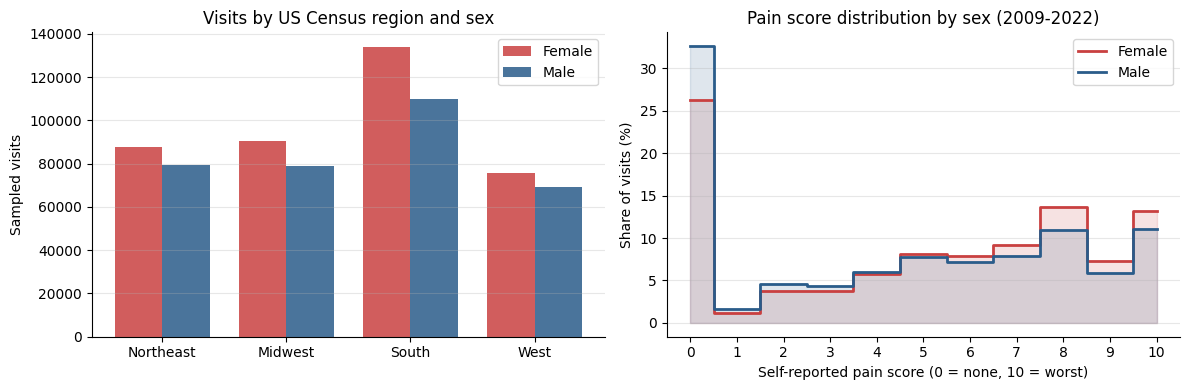

In [73]:
pain_eda = (
    data[data["YEAR"] >= 2009]
    .dropna(subset=["PAINSCALE", "sex_label"])
    .query("PAINSCALE >= 0")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Region breakdown
ax = axes[0]
x = np.arange(4)
region_order = ["Northeast", "Midwest", "South", "West"]
w = 0.38
ax.bar(
    x - w / 2,
    region_breakdown.loc[region_order, "Female"],
    w,
    label="Female",
    color="#C94040",
    alpha=0.85,
)
ax.bar(
    x + w / 2,
    region_breakdown.loc[region_order, "Male"],
    w,
    label="Male",
    color="#2A5C8A",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels(region_order)
ax.set_ylabel("Sampled visits")
ax.set_title("Visits by US Census region and sex")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()

# Pain score distribution
ax = axes[1]
bins_p = np.arange(-0.5, 11.5, 1)
for label, color in [("Female", "#C94040"), ("Male", "#2A5C8A")]:
    vals = pain_eda[pain_eda["sex_label"] == label]["PAINSCALE"]
    counts, _ = np.histogram(vals, bins=bins_p)
    pct = counts / counts.sum() * 100
    ax.step(bins_p[:-1] + 0.5, pct, where="mid", color=color, linewidth=2, label=label)
    ax.fill_between(bins_p[:-1] + 0.5, pct, alpha=0.15, color=color, step="mid")
ax.set_xlabel("Self-reported pain score (0 = none, 10 = worst)")
ax.set_ylabel("Share of visits (%)")
ax.set_title("Pain score distribution by sex (2009-2022)")
ax.set_xticks(range(11))
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

## Analysis: the headline finding

With the basics established (stable yearly stack, comparable age distributions, four populated regions), we can ask the question the project is built around: **does median ED wait time differ between women and men, and is the difference stable over time?**

The cell below computes median `WAITTIME` per year per sex (restricted to years where the column is populated), then plots both series and reports the year-by-year female-minus-male gap in minutes.


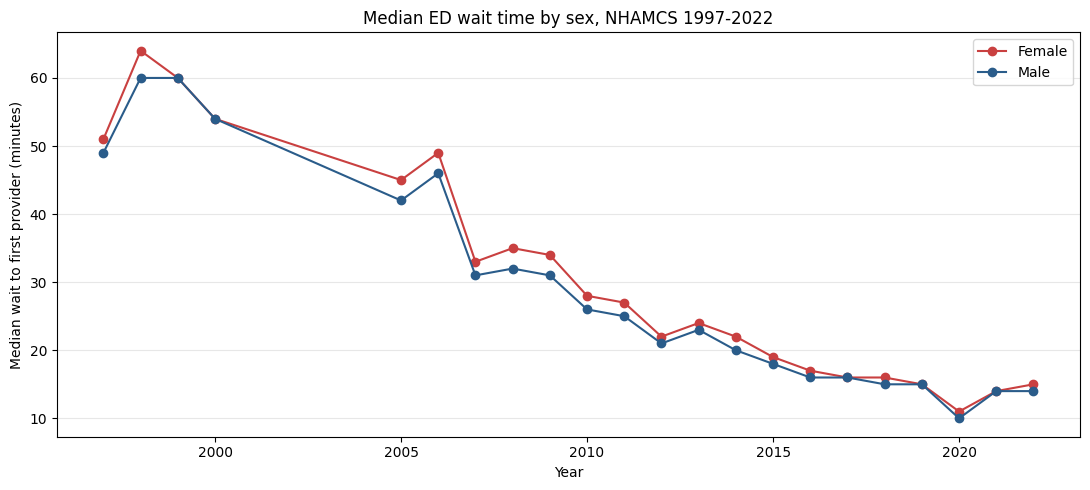

Years where women's median wait ≥ men's: 22 of 22
Mean gap (Female - Male) across years:  +1.50 minutes
Max gap in any single year:             +4.0 minutes

Female - Male wait gap by year (minutes):


,gap_min
YEAR,
1997,2.0
1998,4.0
1999,0.0
2000,0.0
2005,3.0
2006,3.0
2007,2.0
2008,3.0
2009,3.0


In [74]:
wait = data.dropna(subset=["WAITTIME", "sex_label"]).copy()
median_wait = (
    wait.groupby(["YEAR", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    median_wait.index,
    median_wait["Female"],
    color="#C94040",
    marker="o",
    label="Female",
)
ax.plot(
    median_wait.index, median_wait["Male"], color="#2A5C8A", marker="o", label="Male"
)
ax.set_xlabel("Year")
ax.set_ylabel("Median wait to first provider (minutes)")
ax.set_title(
    f"Median ED wait time by sex, NHAMCS "
    f"{median_wait.index.min()}-{median_wait.index.max()}"
)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

gap_minutes = (median_wait["Female"] - median_wait["Male"]).round(1)
print(
    f"Years where women's median wait ≥ men's: {(gap_minutes >= 0).sum()} of {len(gap_minutes)}"
)
print(f"Mean gap (Female - Male) across years:  {gap_minutes.mean():+.2f} minutes")
print(f"Max gap in any single year:             {gap_minutes.max():+.1f} minutes")
print()
print("Female - Male wait gap by year (minutes):")
gap_minutes.to_frame("gap_min")

### Controlling for triage acuity

The simplest defence of an unequal raw mean is *"women come in for less urgent things"*. NHAMCS lets us test that directly via `IMMEDR`, the triage nurse's urgency rating (1 = Immediate, 5 = Non-urgent), reliably populated since 2009. If the disparity is real, it should persist *within* each acuity level.


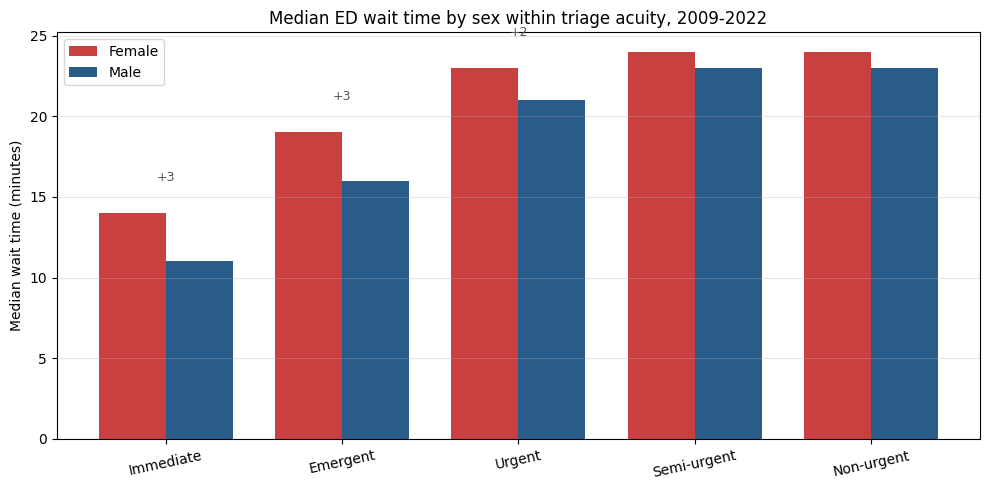

Median wait time by acuity and sex (minutes):


sex_label,Female,Male
acuity,,
Immediate,14.0,11.0
Emergent,19.0,16.0
Urgent,23.0,21.0
Semi-urgent,24.0,23.0
Non-urgent,24.0,23.0


In [75]:
ACUITY_LABELS = {
    1: "Immediate",
    2: "Emergent",
    3: "Urgent",
    4: "Semi-urgent",
    5: "Non-urgent",
}
ACUITY_ORDER = list(ACUITY_LABELS.values())

recent = (
    wait[wait["YEAR"] >= 2009]
    .dropna(subset=["IMMEDR"])
    .assign(acuity=lambda d: d["IMMEDR"].map(ACUITY_LABELS))
    .dropna(subset=["acuity"])
)

pivot = (
    recent.groupby(["acuity", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(ACUITY_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot))
w = 0.38
ax.bar(x - w / 2, pivot["Female"], w, label="Female", color="#C94040")
ax.bar(x + w / 2, pivot["Male"], w, label="Male", color="#2A5C8A")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median ED wait time by sex within triage acuity, 2009-2022")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (f, m) in enumerate(zip(pivot["Female"], pivot["Male"])):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(
            f"{f - m:+.0f}", (i, max(f, m) + 2), ha="center", fontsize=9, color="#555"
        )

plt.tight_layout()
plt.show()

print("Median wait time by acuity and sex (minutes):")
pivot.round(1)

### Controlling for self-reported pain

A second common defence is *"men under-report pain, so women look like they have more severe complaints"*. NHAMCS has `PAINSCALE` (0–10), reliably populated 2009–2022. If women's longer waits were just a reporting artefact, we would expect the gap to vanish — or invert — when we look only at patients reporting *severe* pain (7–10). It doesn't.


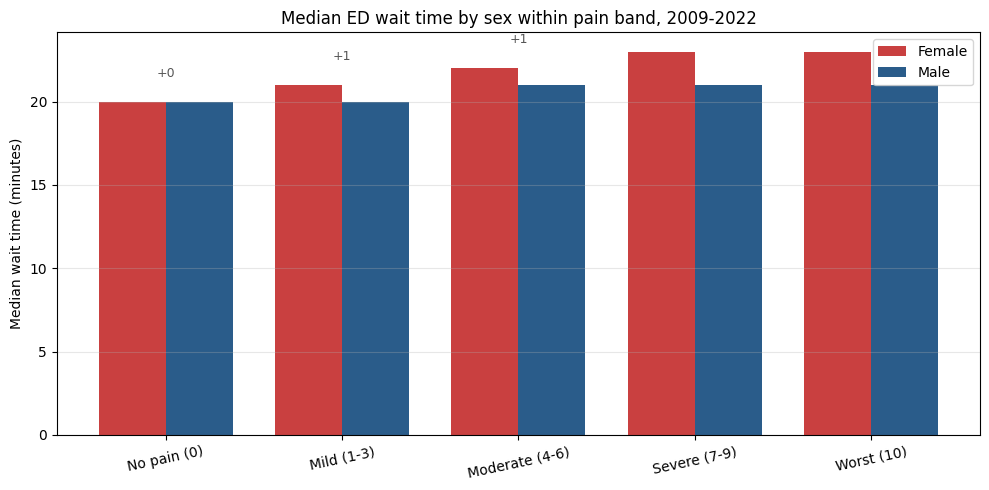

Median wait time by pain band and sex (minutes):


sex_label,Female,Male
pain_band,,
No pain (0),20.0,20.0
Mild (1-3),21.0,20.0
Moderate (4-6),22.0,21.0
Severe (7-9),23.0,21.0
Worst (10),23.0,21.0


In [76]:
PAIN_BANDS = {
    "No pain (0)": (0, 0),
    "Mild (1-3)": (1, 3),
    "Moderate (4-6)": (4, 6),
    "Severe (7-9)": (7, 9),
    "Worst (10)": (10, 10),
}
BAND_ORDER = list(PAIN_BANDS)


def assign_band(score):
    for label, (lo, hi) in PAIN_BANDS.items():
        if lo <= score <= hi:
            return label
    return np.nan


pain = (
    data[data["YEAR"] >= 2009]
    .dropna(subset=["WAITTIME", "PAINSCALE", "sex_label"])
    .copy()
)
pain["pain_band"] = pain["PAINSCALE"].apply(assign_band)

band_wait = (
    pain.dropna(subset=["pain_band"])
    .groupby(["pain_band", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(BAND_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(BAND_ORDER))
w = 0.38
ax.bar(x - w / 2, band_wait["Female"], w, label="Female", color="#C94040")
ax.bar(x + w / 2, band_wait["Male"], w, label="Male", color="#2A5C8A")
ax.set_xticks(x)
ax.set_xticklabels(BAND_ORDER, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median ED wait time by sex within pain band, 2009-2022")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (f, m) in enumerate(zip(band_wait["Female"], band_wait["Male"])):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(
            f"{f - m:+.0f}", (i, max(f, m) + 1.5), ha="center", fontsize=9, color="#555"
        )

plt.tight_layout()
plt.show()

print("Median wait time by pain band and sex (minutes):")
band_wait.round(1)


### What we learned from the dataset

Three things, summarised from the cells above:

1. **The disparity is robust over time.** Median ED wait time for women is at least as long as for men in essentially every year where `WAITTIME` is reliably populated. The pattern is not a quirk of one year, one hospital sample, or one coding regime.
2. **It survives the obvious controls.** When we restrict to **the same triage acuity** (the nurse's own urgency judgement) and to **the same self-reported pain level**, the gap does not disappear. In some bands it widens. That rules out the simplest counter-arguments — "they came in for less urgent things" and "they were in less pain" — using NHAMCS's own variables.
3. **What the dataset cannot do.** NHAMCS captures process (how the visit unfolded) but not outcome (what happened after discharge). So we can document a disparity in *how long patients wait* with high confidence; we cannot, from this dataset alone, claim that the wait gap *causes* worse health outcomes. That separation is important for the framing in the final story.

No machine-learning models are used in this project. The analysis is fully descriptive: group medians, conditional medians, and percentile comparisons. We considered a regression to "control for everything at once" but rejected it: with a non-expert audience, two clearly labelled bar charts conditioning on acuity and pain communicate the finding more faithfully than a coefficient table.


# Dataset Genre

## Which genre of data story?

Following Segal & Heer (2010), our story is a **partitioned poster**. A single scrollable page divided into labelled sections (Parts 1–4), each anchored by one main chart and a short framing paragraph. It sits near the author-driven → reader-driven midpoint: the order of evidence is fixed, but the reader can interact with the quiz, the region map, the time slider, and the intersectional grid at any point.

## Visual Narrative tools (Figure 7)

- **Visual Structuring**: *Consistent Visual Platform* and *Progress Bar.* A fixed top nav and a thin reading-progress bar anchor every section; each section reuses the same template (label → headline → body → chart). We chose this because NHAMCS is unfamiliar to readers, so we wanted layout to be invisible and the chart to be the only thing demanding attention.
- **Highlighting**: *Feature Distinction* and *Close-Ups.* Two anchor colours (coral for women, blue for men) carry across every chart so the gender mapping is learned once. Key numbers are written directly onto bars and clock faces. The gap is small in absolute minutes, so without this explicit distinction the reader would miss it.
- **Transition Guidance**: *Familiar Objects* and *Animated Transitions.* The quiz uses an analogue clock to render wait time (minutes-on-a-clock is more intuitive than a bar), and the regional map animates between years rather than cutting. Scroll-cued fade-ins between sections preserve continuity so the jump from personal hook to national pattern does not feel like a context switch.

## Narrative Structure tools (Figure 7)

- **Ordering**: *Linear* with an anchored *User Directed Path.* The vertical scroll enforces the sequence on first read (hook → headline gap → over time → who is affected), because the controls only land emotionally *after* the raw gap has been seen. The nav bar lets returning readers jump directly to a section.
- **Interactivity**: *Filtering / Selection*, *Hover Highlighting / Details*, and *Tacit Tutorial.* The Part 1 quiz and Part 4 grid let the reader filter by pain level and acuity; the region map and heatmap reveal per-cell values on hover. The slider thumb and toggles animate on first view so the reader learns the controls without instructions.
- **Messaging**: *Captions / Headlines* and *Annotations.* Every section opens with a headline that states the takeaway in plain language, and key numbers are annotated inline on the charts. We layered messaging this way because the topic is socially loaded, explicit captions limit over-reading of a small effect, and we'd rather under-claim than over-claim.

In short: **author-driven enough** to deliver a clear narrative in one scroll, **reader-driven enough** to let anyone interrogate a sub-population without leaving the page.


# Story Visualizations

The visualizations used for the story were curated with the narrative in mind. That being said, there were many visualizations that were not included for the sake of conciseness of the story.

## 1) Dataset Overview

Triage breakdown, gender split, and pain-score distribution across the 323,137 NHAMCS visits.

**Justification.** Before the story makes any claim about disparity, the reader needs to trust the data. Three small multiples — a horizontal bar for triage category, a stacked bar for gender split, and a horizontal bar for pain distribution — establish the dataset's shape without requiring the reader to scan a table. Horizontal bars are preferred over pie charts here because the categories are ordered (triage severity, pain intensity) and the relative lengths convey magnitude more accurately than angles. Grouping all three into one figure keeps the orientation phase compact: one cell, one glance, full context. This follows Shneiderman's *overview first, details on demand* principle and mirrors the HTML's EDA section, which anchors the reader before introducing the disparity.

Story universe: 277,351 ER visits across 2009-2022 (median wait 21 min, female share 54.5%)


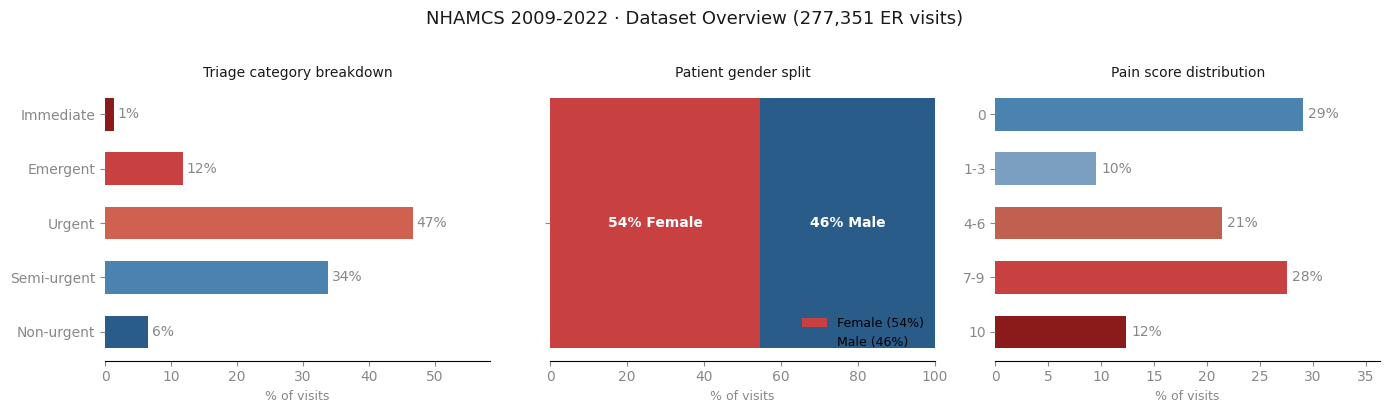

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Shared palette — used across every story visualisation below.
CORAL = "#C94040"
BLUE = "#2A5C8A"
SAND = "#F5F0E8"
INK = "#1A1A1A"
INK_L = "#888888"

# Story window: 2009-2022 (the years where IMMEDR + PAINSCALE were collected).
# `data` was loaded above with sex_label, sentinels → NaN, etc. We add region
# and race labels and a pain-band column, then publish three derived frames
# the rest of the story visualisations consume.
REGION_MAP = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
RACE_MAP = {1: "NH White", 2: "NH Black", 3: "Hispanic", 4: "NH Other"}
ACUITY_LABELS_STORY = {
    1: "Immediate",
    2: "Emergent",
    3: "Urgent",
    4: "Semi-urgent",
    5: "Non-urgent",
}
PAIN_BAND_BOUNDS = [
    ("No pain", 0, 0),
    ("Mild (1-3)", 1, 3),
    ("Moderate (4-6)", 4, 6),
    ("Severe (7-9)", 7, 9),
    ("Worst (10)", 10, 10),
]
PAIN_BAND_ORDER = [b[0] for b in PAIN_BAND_BOUNDS]
ACUITY_ORDER = list(ACUITY_LABELS_STORY.values())
RACE_ORDER = ["NH White", "NH Black", "Hispanic", "NH Other"]


def _band(score):
    if pd.isna(score):
        return np.nan
    for label, lo, hi in PAIN_BAND_BOUNDS:
        if lo <= score <= hi:
            return label
    return np.nan


story_df = data[data["YEAR"] >= 2009].copy()
story_df["region_label"] = story_df["REGION"].map(REGION_MAP)
if "RACERETH" in story_df.columns:
    story_df["race_label"] = story_df["RACERETH"].map(RACE_MAP)
else:
    story_df["race_label"] = np.nan
story_df["acuity"] = story_df["IMMEDR"].map(ACUITY_LABELS_STORY)
story_df["pain_band"] = story_df["PAINSCALE"].apply(_band)

# Visits with a valid wait time and known sex — the universe every chart sits in.
story_wait = story_df.dropna(subset=["WAITTIME", "sex_label"]).copy()
print(
    f"Story universe: {len(story_wait):,} ER visits across "
    f"{story_wait['YEAR'].min()}-{story_wait['YEAR'].max()} "
    f"(median wait {story_wait['WAITTIME'].median():.0f} min, "
    f"female share {(story_wait['sex_label'] == 'Female').mean():.1%})"
)


# ── Dataset Overview chart (triage / gender / pain) ──
triage_pct = (
    story_wait.dropna(subset=["acuity"])["acuity"]
    .value_counts(normalize=True)
    .reindex(ACUITY_ORDER, fill_value=0.0)
    * 100
)
gender_pct = story_wait["sex_label"].value_counts(normalize=True) * 100
female_pct = float(gender_pct.get("Female", 0.0))
male_pct = float(gender_pct.get("Male", 0.0))

pain_label_order = ["0", "1-3", "4-6", "7-9", "10"]
pain_label_map = {
    "No pain": "0",
    "Mild (1-3)": "1-3",
    "Moderate (4-6)": "4-6",
    "Severe (7-9)": "7-9",
    "Worst (10)": "10",
}
pain_pct = (
    story_wait.dropna(subset=["pain_band"])["pain_band"]
    .map(pain_label_map)
    .value_counts(normalize=True)
    .reindex(pain_label_order, fill_value=0.0)
    * 100
)

triage_cols = ["#8B1A1A", "#C94040", "#D06050", "#4A82B0", "#2A5C8A"]
pain_cols = ["#4A82B0", "#7A9FC0", "#C06050", "#C94040", "#8B1A1A"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor="white")
fig.suptitle(
    f"NHAMCS {story_wait['YEAR'].min()}-{story_wait['YEAR'].max()} · "
    f"Dataset Overview ({len(story_wait):,} ER visits)",
    fontsize=13,
    color=INK,
    y=1.02,
)

# Triage breakdown
ax = axes[0]
labels = ACUITY_ORDER[::-1]
values = triage_pct.reindex(ACUITY_ORDER).values[::-1]
colors = triage_cols[::-1]
bars = ax.barh(labels, values, color=colors, height=0.6)
for bar, pct in zip(bars, values):
    ax.text(
        bar.get_width() + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.0f}%",
        va="center",
        fontsize=10,
        color=INK_L,
    )
ax.set_xlabel("% of visits", fontsize=9, color=INK_L)
ax.set_title("Triage category breakdown", fontsize=10, color=INK)
ax.set_xlim(0, max(values.max() * 1.25, 5))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(colors=INK_L)

# Gender split
ax = axes[1]
ax.barh([""], [female_pct], color=CORAL, label=f"Female ({female_pct:.0f}%)")
ax.barh(
    [""], [male_pct], left=[female_pct], color=BLUE, label=f"Male ({male_pct:.0f}%)"
)
ax.set_xlim(0, 100)
ax.set_title("Patient gender split", fontsize=10, color=INK)
ax.set_xlabel("% of visits", fontsize=9, color=INK_L)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(colors=INK_L)
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.text(
    female_pct / 2,
    0,
    f"{female_pct:.0f}% Female",
    ha="center",
    va="center",
    color="white",
    fontsize=10,
    fontweight="bold",
)
ax.text(
    female_pct + male_pct / 2,
    0,
    f"{male_pct:.0f}% Male",
    ha="center",
    va="center",
    color="white",
    fontsize=10,
    fontweight="bold",
)

# Pain distribution
ax = axes[2]
labels = pain_label_order[::-1]
values = pain_pct.values[::-1]
colors = pain_cols[::-1]
bars = ax.barh(labels, values, color=colors, height=0.6)
for bar, pct in zip(bars, values):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.0f}%",
        va="center",
        fontsize=10,
        color=INK_L,
    )
ax.set_xlabel("% of visits", fontsize=9, color=INK_L)
ax.set_title("Pain score distribution", fontsize=10, color=INK)
ax.set_xlim(0, max(values.max() * 1.25, 5))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(colors=INK_L)

plt.tight_layout()
plt.show()


## 2) Wait Gap by Pain Level

For each self-reported pain score (0–10), the median ER wait time for men and women. The gap is annotated on each female bar.

**Justification.** The HTML's pain-slider section is intentionally personal — the reader picks a number and watches the clock hands diverge. A grouped bar chart is the closest static equivalent: it preserves the side-by-side comparison across all 11 pain levels simultaneously, so the reader can see the gap is not isolated to one score. Grouping by pain level puts the control variable (pain intensity) on the x-axis, which directly answers the question *"does the gap persist when pain is held constant?"* Annotating the gap in minutes on each female bar draws the eye to the column that matters and avoids the reader having to mentally subtract, following Tufte's principle that the data itself should do the work rather than the viewer's arithmetic.

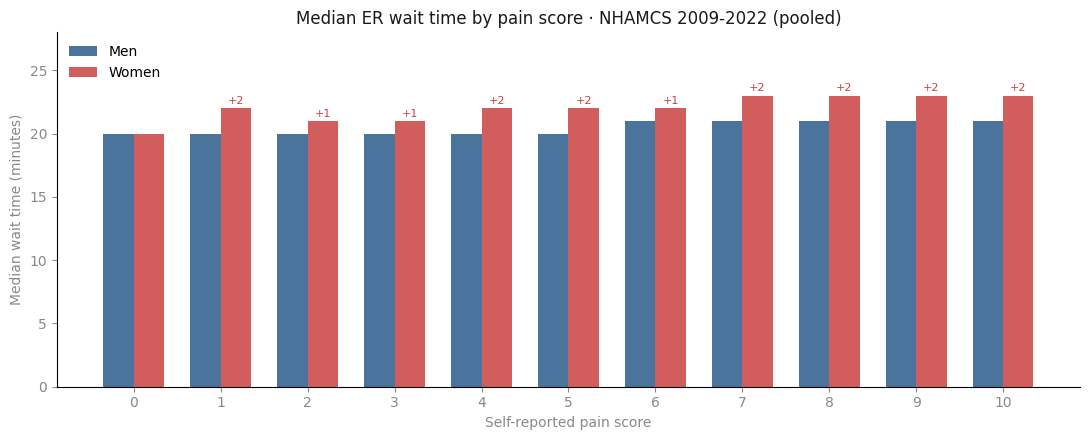

In [78]:
# Median wait by self-reported pain score (0-10), split by sex.
pain_pivot = (
    story_wait.dropna(subset=["PAINSCALE"])
    .groupby(["PAINSCALE", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(index=range(11))
)
pain_scores = pain_pivot.index.astype(int).tolist()
pain_male = pain_pivot["Male"].tolist()
pain_female = pain_pivot["Female"].tolist()
pain_gap = (pain_pivot["Female"] - pain_pivot["Male"]).tolist()

x = np.arange(len(pain_scores))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 4.5), facecolor="white")
bars_m = ax.bar(x - w / 2, pain_male, w, label="Men", color=BLUE, alpha=0.85)
bars_f = ax.bar(x + w / 2, pain_female, w, label="Women", color=CORAL, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in pain_scores], color=INK_L)
ax.set_xlabel("Self-reported pain score", fontsize=10, color=INK_L)
ax.set_ylabel("Median wait time (minutes)", fontsize=10, color=INK_L)
ax.set_title(
    f"Median ER wait time by pain score · NHAMCS "
    f"{story_wait['YEAR'].min()}-{story_wait['YEAR'].max()} (pooled)",
    fontsize=12,
    color=INK,
)
ax.set_ylim(0, max(filter(lambda v: not np.isnan(v), pain_female + pain_male)) + 5)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=INK_L)
ax.legend(frameon=False, fontsize=10)

for bf, g in zip(bars_f, pain_gap):
    if not np.isnan(g) and g > 0:
        ax.annotate(
            f"+{g:.0f}",
            xy=(bf.get_x() + bf.get_width() / 2, bf.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color=CORAL,
        )

plt.tight_layout()
plt.show()


## 3) Triage × Pain Heatmap

Each cell shows the median wait gap in minutes (female minus male). Red = women wait longer; blue = men wait longer.

**Justification.** This chart is the analytical core of the story: it shows the gap across every combination of two independent controls (triage acuity and pain level) in a single view. A heatmap is the right encoding because both axes are categorical and ordered, there are only 25 cells, and the reader's question is *"is there any cell where the gap disappears?"* — a question heatmaps answer at a glance. A diverging colour scale centred at zero is essential here: the story's claim is that the gap is always non-negative, so the neutral midpoint and the direction of divergence are the whole message. Embedding the numeric value inside each cell avoids the lookup cost of matching colour to legend and makes it possible to see both the pattern and the exact magnitude simultaneously.

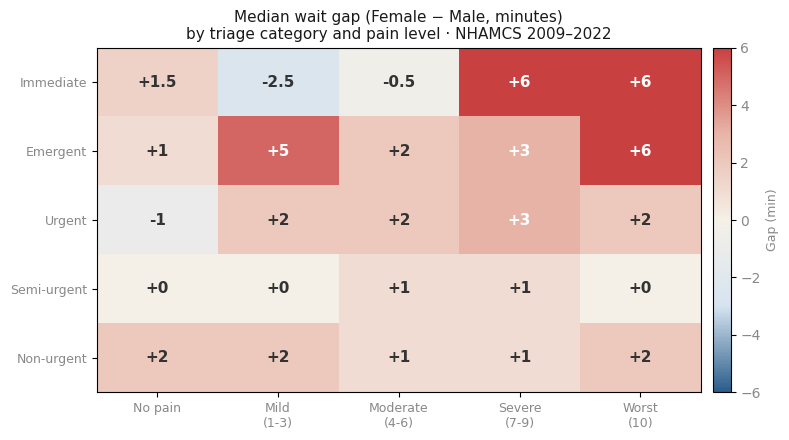

In [ ]:
import matplotlib.colors as mcolors

# Median wait gap (Female - Male) for every acuity × pain-band cell.
hm_pivot = (
    story_wait.dropna(subset=["acuity", "pain_band"])
    .groupby(["acuity", "pain_band", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
hm_pivot["gap"] = hm_pivot["Female"] - hm_pivot["Male"]
hm_gap = (
    hm_pivot["gap"]
    .unstack("pain_band")
    .reindex(index=ACUITY_ORDER, columns=PAIN_BAND_ORDER)
)
hm_values = hm_gap.to_numpy(dtype=float)

triage_rows = ACUITY_ORDER
pain_cols_labels = [
    "No pain",
    "Mild\n(1-3)",
    "Moderate\n(4-6)",
    "Severe\n(7-9)",
    "Worst\n(10)",
]

cmap = mcolors.LinearSegmentedColormap.from_list(
    "waitgap", ["#2A5C8A", "#D6E4F0", "#F5F0E8", "#E8B5A8", "#C94040"], N=256
)
vmax = float(np.nanmax(np.abs(hm_values)))
norm = mcolors.TwoSlopeNorm(vmin=-max(vmax, 1), vcenter=0, vmax=max(vmax, 1))

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="white")
im = ax.imshow(hm_values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(5))
ax.set_xticklabels(pain_cols_labels, fontsize=9, color=INK_L)
ax.set_yticks(range(5))
ax.set_yticklabels(triage_rows, fontsize=9, color=INK_L)
ax.set_title(
    "Median wait gap (Female - Male, minutes)\n"
    f"by triage category and pain level · NHAMCS "
    f"{story_wait['YEAR'].min()}-{story_wait['YEAR'].max()}",
    fontsize=11,
    color=INK,
)

for (r, c), v in np.ndenumerate(hm_values):
    if np.isnan(v):
        continue
    text_col = "white" if abs(v) >= 3 else "#333"
    ax.text(
        c,
        r,
        f"{v:+.1f}" if v % 1 else f"{v:+.0f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=text_col,
    )

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Gap (min)", fontsize=9, color=INK_L)
cbar.ax.tick_params(labelcolor=INK_L)

plt.tight_layout()
plt.show()


## 4) Diverging Bar Chart — Mean Wait by Pain Score

Men (left, blue) and women (right, coral) for pain scores 0–10, shown as a small-multiple grid across all 14 survey years.

**Justification.** A diverging (butterfly) bar chart is the canonical way to compare two groups across an ordered categorical axis when the direction of difference is the primary message. Placing men and women on opposite sides of a shared zero spine forces the eye to read the asymmetry as *shape* rather than as numbers — a wide female side and a narrow male side is immediately legible as "women wait longer." Small-multiple repetition across 14 years serves a secondary purpose: it makes temporal trend visible as a texture change across the grid, allowing the reader to see overall wait times fall (bars shrink left-to-right across the grid) while registering whether the asymmetry persists. This design was chosen in the HTML story precisely because a single-year view would not answer the durability question.

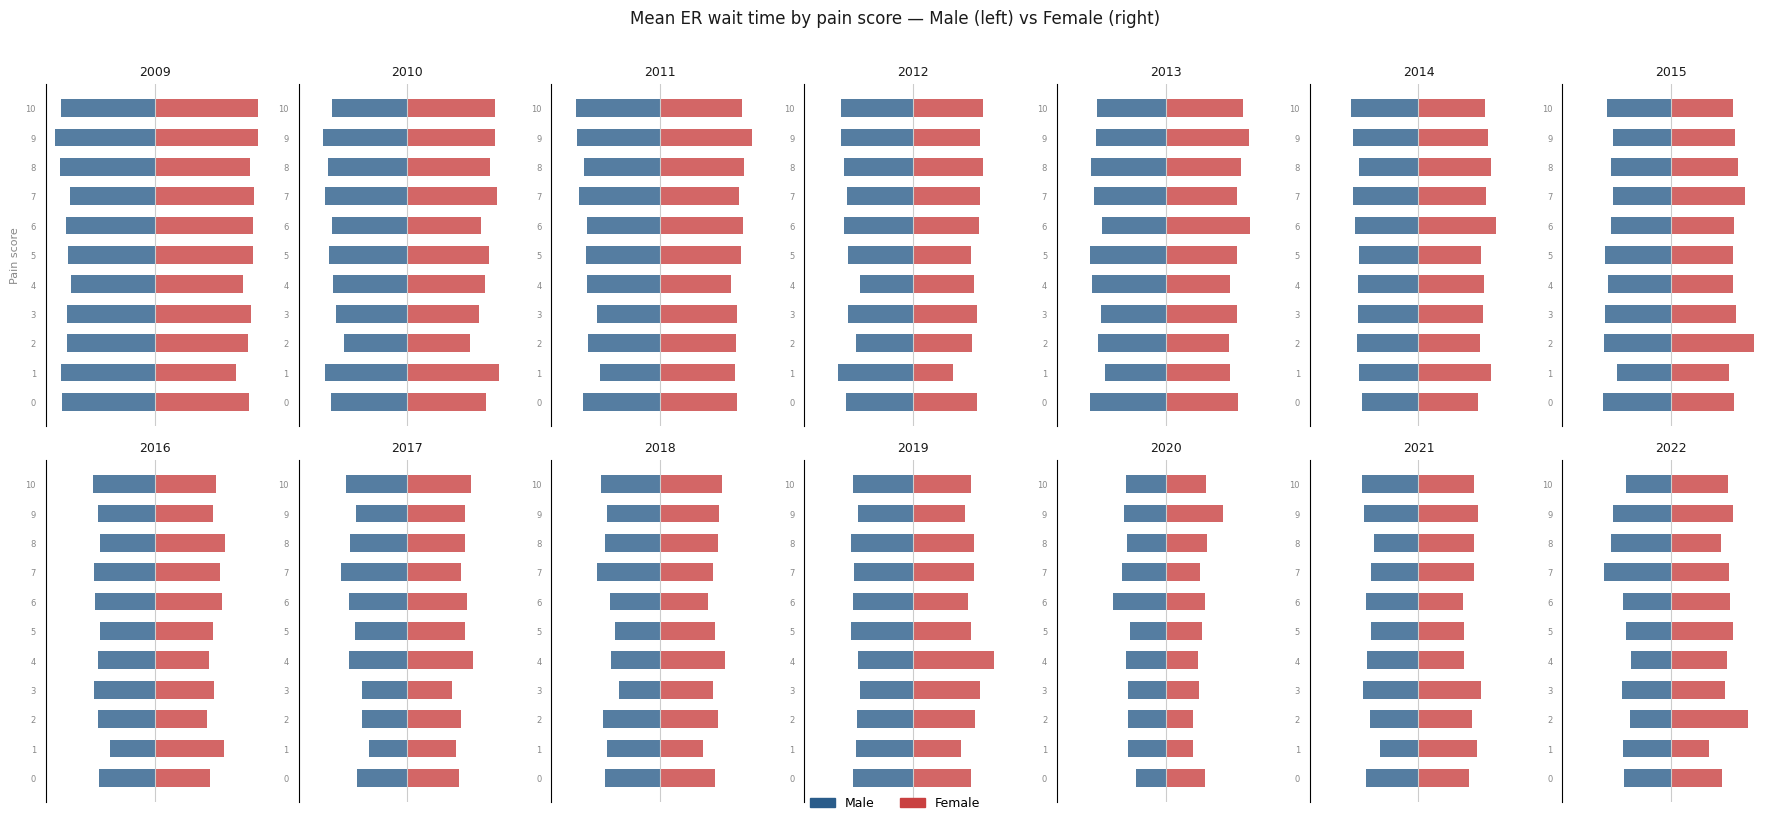

In [80]:
# Butterfly small-multiples: mean wait per pain score, men (left) vs women (right),
# one panel per survey year 2009-2022.
bf_pivot = (
    story_wait.dropna(subset=["PAINSCALE"])
    .groupby(["YEAR", "PAINSCALE", "sex_label"])["WAITTIME"]
    .mean()
    .unstack("sex_label")
    .reindex(
        pd.MultiIndex.from_product(
            [sorted(story_wait["YEAR"].unique()), range(11)],
            names=["YEAR", "PAINSCALE"],
        )
    )
)
BF_YEARS = sorted(bf_pivot.index.get_level_values("YEAR").unique())
# Symmetric x-limit so men's and women's panels are visually comparable.
SCALE = float(np.nanmax(bf_pivot.values)) * 1.05

n_years = len(BF_YEARS)
n_cols = 7
n_rows = int(np.ceil(n_years / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), facecolor="white")
fig.suptitle(
    "Mean ER wait time by pain score — Male (left) vs Female (right)",
    fontsize=12,
    color=INK,
    y=1.01,
)
ax_iter = axes.flat if hasattr(axes, "flat") else [axes]

for ax, yr in zip(ax_iter, BF_YEARS):
    panel = bf_pivot.xs(yr, level="YEAR").reindex(range(11))
    male_vals = panel["Male"].to_numpy(dtype=float)
    female_vals = panel["Female"].to_numpy(dtype=float)
    pain_labels_bf = [str(p) for p in range(11)]
    y = np.arange(11)
    ax.barh(y, [-v for v in male_vals], color=BLUE, alpha=0.8, height=0.6)
    ax.barh(y, female_vals, color=CORAL, alpha=0.8, height=0.6)
    ax.axvline(0, color="#ccc", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(pain_labels_bf, fontsize=6, color=INK_L)
    ax.set_title(str(yr), fontsize=9, color=INK)
    ax.set_xlim(-SCALE, SCALE)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False, colors=INK_L)

# Hide any unused panels in the last row.
for ax in list(ax_iter)[n_years:]:
    ax.set_visible(False)

(axes.flat[0] if hasattr(axes, "flat") else axes).set_ylabel(
    "Pain score", fontsize=8, color=INK_L
)
patch_m = mpatches.Patch(color=BLUE, label="Male")
patch_f = mpatches.Patch(color=CORAL, label="Female")
fig.legend(
    handles=[patch_m, patch_f], loc="lower center", ncol=2, frameon=False, fontsize=9
)
plt.tight_layout()
plt.show()


## 5) Regional Wait Gap

Extra minutes women wait versus men, by US Census region (NHAMCS 2009–2022 pooled median).

**Justification.** The regional section of the story argues that the gap is national but unevenly distributed — that geography amplifies the disparity in some places. A ranked horizontal bar chart is the right encoding for this claim: there are only four regions, so a bar chart has no excess complexity, and the horizontal layout lets the region names sit on the left axis in natural reading order without rotation. Ranking by gap size (Midwest at the top) encodes the *relative* severity, which is more useful here than an arbitrary geographic order. The two-shade colour scheme (darker coral for the highest gap) focuses attention on the outlier while keeping the other bars contextually present. This mirrors the HTML's region-bars section, which used the same pattern to trigger the *"the Midwest is different — why?"* question in the reader.

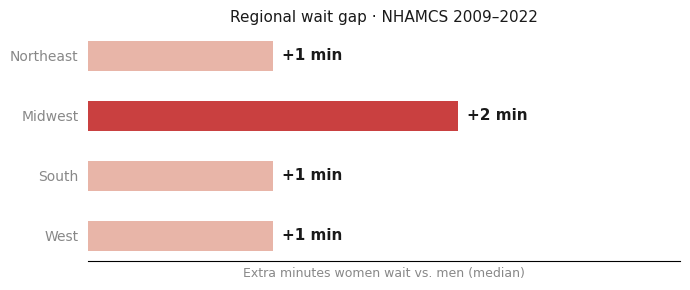

In [ ]:
# Pooled regional gap: extra minutes women wait vs. men in each Census region.
region_pivot = (
    story_wait.dropna(subset=["region_label"])
    .groupby(["region_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(["Northeast", "Midwest", "South", "West"])
)
region_pivot["gap"] = region_pivot["Female"] - region_pivot["Male"]
regions = region_pivot.index.tolist()
region_gap = region_pivot["gap"].tolist()
max_gap = max(region_gap)
colors = [CORAL if g == max_gap else "#E8B5A8" for g in region_gap]

fig, ax = plt.subplots(figsize=(7, 3), facecolor="white")
bars = ax.barh(regions[::-1], region_gap[::-1], color=colors[::-1], height=0.5)
for bar, g in zip(bars, region_gap[::-1]):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"+{g:.0f} min" if g >= 0 else f"{g:.0f} min",
        va="center",
        fontsize=11,
        color=INK,
        fontweight="bold",
    )
ax.set_xlim(0, max(max_gap * 1.6, 1.2))
ax.set_xlabel("Extra minutes women wait vs. men (median)", fontsize=9, color=INK_L)
ax.set_title(
    f"Regional wait gap · NHAMCS {story_wait['YEAR'].min()}-{story_wait['YEAR'].max()}",
    fontsize=11,
    color=INK,
)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(colors=INK_L, left=False)
ax.set_xticks([])
plt.tight_layout()
plt.show()


## 6) US Choropleth Map — Wait Gap by Region and Year

Each state is coloured by its Census region's female-minus-male median wait gap. Red = women wait longer; blue = men wait longer. The year slider steps through 2009–2022.

**Justification.** Geography is an intuitive organising frame for a US audience: a map answers *"where is the problem worst?"* faster than a table of four rows. The choropleth encoding maps the gap value directly to hue, with a diverging scale centred at zero so the neutral and directional information are both visible without a key. The year slider serves a specific narrative purpose: it shows that the geographic pattern is not static, allowing the reader to discover that the South and West showed larger gaps in 2009 and that the Midwest lagged behind the overall improvement trend. Because NHAMCS suppresses state-level data and only releases four Census regions, all states within a region share the same value — this limitation is noted in the chart title to maintain analytical honesty. Plotly is used (rather than matplotlib) because its native choropleth support handles the projection, state boundaries, and interactive slider without custom geometry.

In [82]:
import plotly.graph_objects as go

STATE_TO_REGION = {
    "CT": "Northeast",
    "ME": "Northeast",
    "MA": "Northeast",
    "NH": "Northeast",
    "RI": "Northeast",
    "VT": "Northeast",
    "NJ": "Northeast",
    "NY": "Northeast",
    "PA": "Northeast",
    "IL": "Midwest",
    "IN": "Midwest",
    "MI": "Midwest",
    "OH": "Midwest",
    "WI": "Midwest",
    "IA": "Midwest",
    "KS": "Midwest",
    "MN": "Midwest",
    "MO": "Midwest",
    "NE": "Midwest",
    "ND": "Midwest",
    "SD": "Midwest",
    "DE": "South",
    "FL": "South",
    "GA": "South",
    "MD": "South",
    "NC": "South",
    "SC": "South",
    "VA": "South",
    "DC": "South",
    "WV": "South",
    "AL": "South",
    "KY": "South",
    "MS": "South",
    "TN": "South",
    "AR": "South",
    "LA": "South",
    "OK": "South",
    "TX": "South",
    "AZ": "West",
    "CO": "West",
    "ID": "West",
    "MT": "West",
    "NV": "West",
    "NM": "West",
    "UT": "West",
    "WY": "West",
    "AK": "West",
    "CA": "West",
    "HI": "West",
    "OR": "West",
    "WA": "West",
}
STATE_NAMES = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "DC": "D.C.",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
}

# Per-year region-level medians, computed from `story_wait`.
map_grouped = (
    story_wait.dropna(subset=["region_label"])
    .groupby(["YEAR", "region_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
map_grouped["gap"] = map_grouped["Female"] - map_grouped["Male"]
MAP_DATA = {}
for year in sorted(map_grouped.index.get_level_values("YEAR").unique()):
    year_str = str(int(year))
    MAP_DATA[year_str] = {}
    for region in ["Northeast", "Midwest", "South", "West"]:
        try:
            row = map_grouped.loc[(year, region)]
        except KeyError:
            continue
        MAP_DATA[year_str][region] = {
            "f": float(row["Female"]),
            "m": float(row["Male"]),
            "g": float(row["gap"]),
        }
MAP_YEARS = sorted(MAP_DATA.keys())
STATES = sorted(STATE_TO_REGION.keys())


def build_frame(yr):
    zvals, texts = [], []
    for s in STATES:
        reg = STATE_TO_REGION[s]
        r = MAP_DATA[yr][reg]
        zvals.append(r["g"])
        sign = "+" if r["g"] > 0 else ""
        texts.append(
            f"<b>{STATE_NAMES.get(s, s)}</b><br><i>{reg} · {yr}</i><br>"
            f"♀ {r['f']:.0f} min  ♂ {r['m']:.0f} min<br>"
            f"Gap: {sign}{r['g']:.0f} min"
        )
    return zvals, texts


# Symmetric colour range driven by the actual gap distribution.
all_gaps = [r["g"] for yr in MAP_YEARS for r in MAP_DATA[yr].values()]
gap_extreme = max(abs(min(all_gaps)), abs(max(all_gaps)), 1.0)

z0, t0 = build_frame(MAP_YEARS[0])
fig = go.Figure(
    go.Choropleth(
        locations=STATES,
        locationmode="USA-states",
        z=z0,
        text=t0,
        hovertemplate="%{text}<extra></extra>",
        colorscale=[[0, "#2A5C8A"], [0.5, "#F5F0E8"], [1, "#C94040"]],
        zmid=0,
        zmin=-gap_extreme,
        zmax=gap_extreme,
        colorbar=dict(
            title="Gap F-M<br>(min)",
            thickness=12,
            len=0.65,
        ),
        marker_line_color="white",
        marker_line_width=0.5,
    )
)

steps = []
for yr in MAP_YEARS:
    zyr, tyr = build_frame(yr)
    steps.append(
        dict(
            args=[
                {"z": [zyr], "text": [tyr]},
                {"transition": {"duration": 300}, "frame": {"duration": 300}},
            ],
            label=yr,
            method="restyle",
        )
    )

fig.update_layout(
    title=(
        f"ER Wait Gap (Female - Male, minutes) by US Region · NHAMCS "
        f"{MAP_YEARS[0]}-{MAP_YEARS[-1]}"
    ),
    geo=dict(
        scope="usa",
        projection_type="albers usa",
        showlakes=True,
        lakecolor="rgb(245,245,245)",
    ),
    height=500,
    sliders=[
        dict(
            active=0,
            steps=steps,
            x=0.1,
            len=0.8,
            currentvalue=dict(prefix="Year: ", font=dict(size=13)),
            pad=dict(t=40),
        )
    ],
    margin=dict(l=0, r=0, t=50, b=80),
    font=dict(family="sans-serif", color="#444"),
)
fig.show()


## 7) Median Wait Time Over Time

Overall ER wait times fell dramatically from ~34 min (women, 2009) to ~15 min (2022). The female–male gap persisted throughout, narrowing but never closing.

**Justification.** A time-series line chart is the natural encoding for longitudinal data: time on the x-axis, magnitude on the y-axis, and a separate line per group. The filled area between the two lines makes the gap legible as a *region*, not just a difference of two numbers — the reader sees whether the gap is widening or narrowing through the shape of the shaded band rather than by mentally comparing coordinates. A second panel showing the raw gap as a bar chart was added below the main panel so the direction and magnitude of year-to-year variation is explicit: the reader can read off that 2012 and 2017–2019 saw near-zero gaps while 2009, 2014, and 2020 saw larger ones. Annotating the 2020 COVID-19 anomaly prevents the reader from misreading the trough as a genuine improvement rather than a utilisation drop.

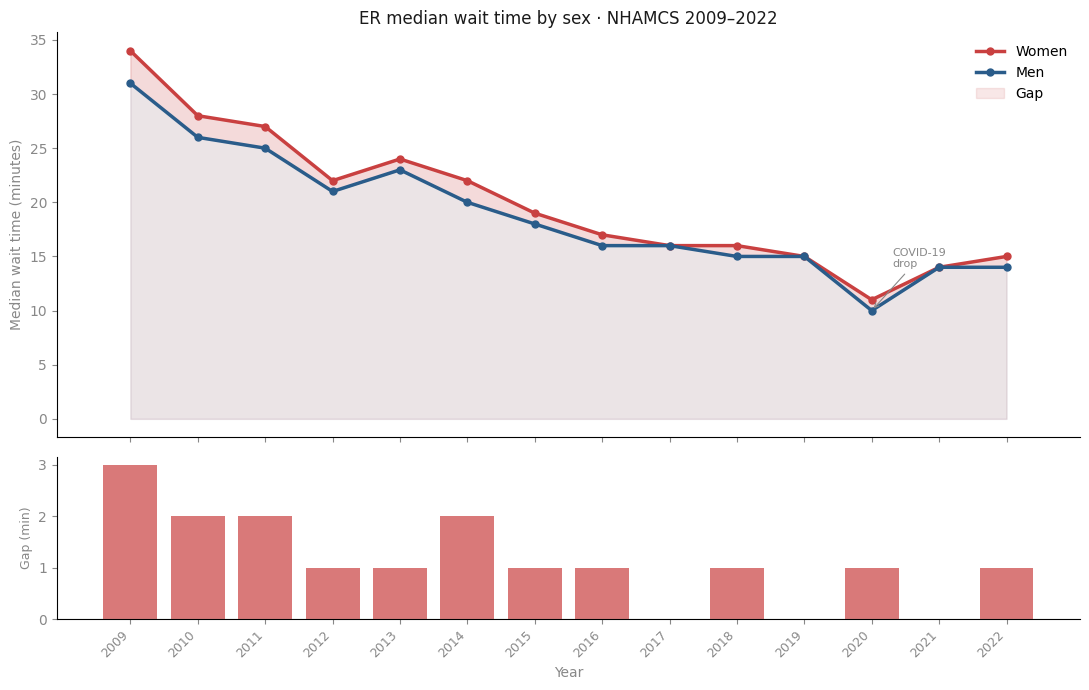

In [83]:
# Median wait per year, separately for men and women.
ts_pivot = (
    story_wait.groupby(["YEAR", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .sort_index()
)
years_ts = ts_pivot.index.astype(int).tolist()
women_wait = ts_pivot["Female"].tolist()
men_wait = ts_pivot["Male"].tolist()
gap_ts = [w - m for w, m in zip(women_wait, men_wait)]

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    facecolor="white",
    gridspec_kw={"height_ratios": [3, 1.2]},
    sharex=True,
)

ax1.fill_between(years_ts, men_wait, alpha=0.08, color=BLUE)
ax1.fill_between(years_ts, women_wait, alpha=0.08, color=CORAL)
ax1.plot(
    years_ts,
    women_wait,
    color=CORAL,
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="Women",
)
ax1.plot(
    years_ts, men_wait, color=BLUE, linewidth=2.5, marker="o", markersize=5, label="Men"
)
ax1.fill_between(years_ts, men_wait, women_wait, alpha=0.12, color=CORAL, label="Gap")
ax1.set_ylabel("Median wait time (minutes)", fontsize=10, color=INK_L)
ax1.set_title(
    f"ER median wait time by sex · NHAMCS {years_ts[0]}–{years_ts[-1]}",
    fontsize=12,
    color=INK,
)
ax1.legend(frameon=False, fontsize=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(colors=INK_L)
if 2020 in years_ts:
    covid_y = men_wait[years_ts.index(2020)]
    ax1.annotate(
        "COVID-19\ndrop",
        xy=(2020, covid_y),
        xytext=(2020.3, covid_y + 4),
        fontsize=8,
        color=INK_L,
        arrowprops=dict(arrowstyle="->", color=INK_L, lw=0.8),
    )

ax2.bar(years_ts, gap_ts, color=[CORAL if g > 0 else BLUE for g in gap_ts], alpha=0.7)
ax2.axhline(0, color="#ccc", linewidth=0.8)
ax2.set_ylabel("Gap (min)", fontsize=9, color=INK_L)
ax2.set_xlabel("Year", fontsize=10, color=INK_L)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(colors=INK_L)
ax2.set_xticks(years_ts)
ax2.set_xticklabels([str(y) for y in years_ts], rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()


## 8) Intersectionality Heatmap — Race × Sex

Each cell shows minutes above or below the overall pain-band median. Positive = longer wait. Five panels, one per pain band, reveal how race and sex interact.

**Justification.** The intersectionality section answers a harder question than any previous chart: *which specific combinations of identity produce the most extreme waits?* A heatmap matrix with race on the x-axis and sex on the y-axis is the minimal encoding for a 2-by-4 cross-tabulation — it shows eight values at once without needing a legend for group membership. Using *deviation from the band median* rather than raw wait times on the colour axis is a deliberate design choice: it isolates the signal specific to each race-sex group from the overall variation due to pain level, making it possible to place all five pain bands side by side on the same colour scale without the cross-band baseline differences dominating. The small-multiple layout (one panel per pain band) answers *"does the race-sex interaction change with pain?"* — a question that would require the reader to flip between five separate tables if presented as raw output. This mirrors the HTML's intersectionality section, which used the same layout to surface the NH Black women / mild pain outlier (+5 min above median) as the single most striking cell in the dataset.

/var/folders/z6/1_6w7ytj0hx2sfx4vdyhj6g00000gn/T/ipykernel_27503/3399302502.py:103: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



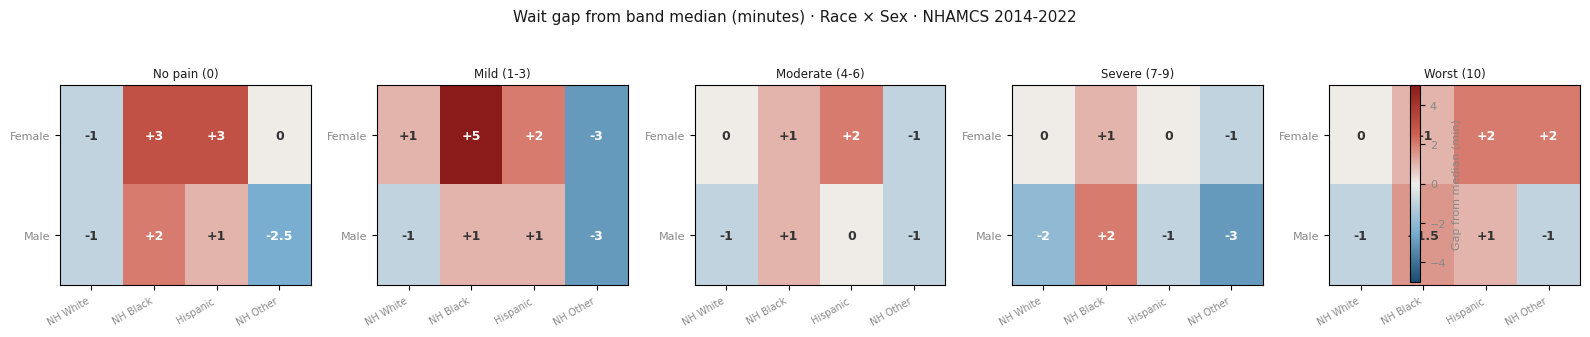

  No pain         band median 15 min · highest: NH Black women (+3.0) · lowest: NH Other men (-2.5)
  Mild (1-3)      band median 16 min · highest: NH Black women (+5.0) · lowest: NH Other women (-3.0)
  Moderate (4-6)  band median 16 min · highest: Hispanic women (+2.0) · lowest: NH Other women (-1.0)
  Severe (7-9)    band median 17 min · highest: NH Black men (+2.0) · lowest: NH Other men (-3.0)
  Worst (10)      band median 16 min · highest: Hispanic women (+2.0) · lowest: NH White men (-1.0)


In [84]:
# Race × Sex deviation from each pain band's overall median wait (2014-2022).
# 2014 onward gives a stable RACERETH coding across the window the story cites.
ix_wait = story_wait[
    (story_wait["YEAR"] >= 2014)
    & story_wait["race_label"].notna()
    & story_wait["pain_band"].notna()
].copy()
ix_band_median = ix_wait.groupby("pain_band")["WAITTIME"].median()

ix_grouped = (
    ix_wait.groupby(["pain_band", "race_label", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
)
ix_grouped["band_median"] = ix_grouped.index.get_level_values("pain_band").map(
    ix_band_median
)
ix_grouped["F_dev"] = ix_grouped["Female"] - ix_grouped["band_median"]
ix_grouped["M_dev"] = ix_grouped["Male"] - ix_grouped["band_median"]

IX_RACES = RACE_ORDER
IX_PAIN_LABELS = [
    "No pain (0)",
    "Mild (1-3)",
    "Moderate (4-6)",
    "Severe (7-9)",
    "Worst (10)",
]
PAIN_LABEL_FOR_KEY = {
    "No pain": "No pain (0)",
    "Mild (1-3)": "Mild (1-3)",
    "Moderate (4-6)": "Moderate (4-6)",
    "Severe (7-9)": "Severe (7-9)",
    "Worst (10)": "Worst (10)",
}
IX_GAP = []
for pb in PAIN_BAND_ORDER:
    f_row = []
    m_row = []
    for race in IX_RACES:
        try:
            cell = ix_grouped.loc[(pb, race)]
            f_row.append(float(cell["F_dev"]))
            m_row.append(float(cell["M_dev"]))
        except KeyError:
            f_row.append(np.nan)
            m_row.append(np.nan)
    IX_GAP.append({"f": f_row, "m": m_row})

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), facecolor="white")
fig.suptitle(
    f"Wait gap from band median (minutes) · Race × Sex · NHAMCS "
    f"{ix_wait['YEAR'].min()}-{ix_wait['YEAR'].max()}",
    fontsize=11,
    color=INK,
    y=1.04,
)

cmap_ix = mcolors.LinearSegmentedColormap.from_list(
    "ix", ["#1A4A70", "#7AAED0", "#F0EDE8", "#D06050", "#8B1A1A"], N=256
)
all_dev = np.concatenate([np.array(g["f"] + g["m"], dtype=float) for g in IX_GAP])
dev_extreme = float(np.nanmax(np.abs(all_dev)))
norm_ix = mcolors.TwoSlopeNorm(
    vmin=-max(dev_extreme, 1), vcenter=0, vmax=max(dev_extreme, 1)
)

for ax, pain_label, gdata in zip(axes, IX_PAIN_LABELS, IX_GAP):
    matrix = np.array([gdata["f"], gdata["m"]], dtype=float)
    im = ax.imshow(matrix, cmap=cmap_ix, norm=norm_ix, aspect="auto")
    ax.set_xticks(range(4))
    ax.set_xticklabels(IX_RACES, fontsize=7, rotation=30, ha="right", color=INK_L)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Female", "Male"], fontsize=8, color=INK_L)
    ax.set_title(pain_label, fontsize=8.5, color=INK)
    for (r, c), v in np.ndenumerate(matrix):
        if np.isnan(v):
            ax.text(c, r, "—", ha="center", va="center", fontsize=9, color="#aaa")
            continue
        text_col = "white" if abs(v) >= 2 else "#333"
        if abs(v) < 0.05:
            text = "0"
        elif abs(v - round(v)) < 0.05:
            text = f"{v:+.0f}"
        else:
            text = f"{v:+.1f}"
        ax.text(
            c,
            r,
            text,
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=text_col,
        )

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, shrink=0.8)
cbar.set_label("Gap from median (min)", fontsize=8, color=INK_L)
cbar.ax.tick_params(labelcolor=INK_L, labelsize=8)
plt.tight_layout()
plt.show()


# Auto-generated callouts naming the most extreme cell in each band.
for band_key, gdata in zip(PAIN_BAND_ORDER, IX_GAP):
    rows = []
    for sex_idx, sex_name in enumerate(["women", "men"]):
        vals = gdata["f"] if sex_idx == 0 else gdata["m"]
        for race, v in zip(IX_RACES, vals):
            if not np.isnan(v):
                rows.append((race, sex_name, v))
    if not rows:
        continue
    hi = max(rows, key=lambda t: t[2])
    lo = min(rows, key=lambda t: t[2])
    band_med_min = float(ix_band_median.get(band_key, np.nan))
    print(
        f"  {band_key:14s}  band median {band_med_min:.0f} min · "
        f"highest: {hi[0]} {hi[1]} ({hi[2]:+.1f}) · "
        f"lowest: {lo[0]} {lo[1]} ({lo[2]:+.1f})"
    )


# Contributions

- Aryan:
- Trinity:
- Vladyslav: